# Lecture 2: MLP Character-Level Language Model

In Lecture 1 I predicted the next character from just one previous character, first by counting bigrams and then with a single-linear-layer neural net. Both landed at the same loss, about 2.45, and the names it generated were weak because one character of context is almost nothing to go on.

The obvious fix is more context, but the counting approach cannot take it. The table grows with the number of possible contexts, and that number explodes:

```
1 character of context  =>        27 contexts
2 characters            =>       729 contexts   (27^2)
3 characters            =>    19,683 contexts   (27^3)
4 characters            =>   531,441 contexts   (27^4)
```

This is the curse of dimensionality: the contexts multiply exponentially while the dataset stays fixed at 228k examples, so most three-character contexts show up once or twice, **far too few counts to trust**. The model cannot learn from what it barely sees.

The way out, and the whole point of this video, is to stop enumerating contexts and instead learn a compressed representation of each character, then combine those. Even if the model never saw the exact context `uma`, it still knows `u`, `m`, and `a` from thousands of other contexts and can reason from there. I follow Bengio et al. 2003, the and build it with the loop: forward pass to a loss, backward to gradients, nudge the parameters downhill.

## The architecture (Bengio et al. 2003)

Three ideas are new relative to Lecture 1.

**1. Embeddings instead of one-hot.** in last lecture a character was a one-hot vector, `e` as `[0,0,0,0,0,1,0,...]`, 27 numbers that are fixed forever and say nothing about how characters relate. Here `e` becomes a short vector of learned numbers, for example `[0.3, -0.7]`. I keep a table `C` of shape `(27, d)`, one row per character, start it random, and let gradient descent move the rows around. Characters that behave alike in names get pulled close together, and that geometry is learned rather than hardcoded. Bengio calls this a distributed representation: what the model knows about a character is spread across several numbers, not pinned to a single index.

**2. Context window plus concatenation.** Instead of one previous character I take the last three, look up each embedding, and concatenate them into one input vector. With 2-dimensional embeddings that is 3 times 2, so 6 numbers feeding the network.

**3. A hidden layer with tanh.** In lecture 1 we used a single linear layer. Stacking two linear layers buys nothing, because `(x @ W1) @ W2` is just `x @ (W1 @ W2)`, one linear layer in disguise. A `tanh` between them bends the signal so the second layer sees something non-linear and can detect patterns no single matrix multiply could. As a concrete picture, `tanh` saturates to -1 for very negative inputs and to +1 for very positive ones, and is roughly linear near 0, and that bend is what lets a hidden unit act as a detector (for example an AND gate that only fires when two inputs are both on).

```
"e", "m", "m"
   |  lookup C
[0.3,-0.7, 1.2,0.1, 1.2,0.1]     concatenated embeddings (6 numbers)
   |  @ W1 + b1
   |  tanh                        the non-linearity
[ ... ]                           hidden layer (100 numbers)
   |  @ W2 + b2
[ ... ]                           27 logits
   |  softmax
[ ... ]                           27 probabilities, sample the next character
```

Everything, `C, W1, b1, W2, b2`, is trained by gradient descent on the negative-log-likelihood loss. It is the same loop as last time, just with more parameters and a richer forward pass.

## Step 0: Setup and data

Same dataset: 32,033 names, one per line, in `names.txt`. I read them into a list and rebuild the character-to-integer tables (`.` is index 0 and doubles as the start and end token, letters are 1 to 26)

In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [7]:
with open("../data/names.txt", "r", encoding="utf-8") as file:
    words = file.read().splitlines()

In [8]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

`stoi` maps each character to an integer and `itos` maps back, so I can turn model output into letters. 27 symbols in total: 26 letters plus the `.` token.

In [9]:
chars = sorted(set(''.join(words)))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(len(stoi))
print(max(stoi.values()))

27
26


## Step 1: Build the training set (X, Y)

The net trains on (input, target) pairs. With a context length of three, each input `X[k]` is a window of three character indices and each target `Y[k]` is the index of the character that actually follows. I slide a window across every name, starting from `[0, 0, 0]` (three dots, nothing seen yet) and moving one character at a time.

For `emma` the windows and targets are:

```
context      ->  target
[., ., .]    ->  e
[., ., e]    ->  m
[., e, m]    ->  m
[e, m, m]    ->  a
[m, m, a]    ->  .     name ends
```

The slide is `context = context[1:] + [ix]`: drop the oldest character, append the new one. I run it on the first five words so the shapes are easy to see.

In [10]:
block_size = 3   # context length, how many characters we use to predict the next one

X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
print(X.shape, Y.shape)

emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .
torch.Size([32, 3]) torch.Size([32])


`X` is `(N, 3)`, N examples each with three character indices, and `Y` is `(N,)`, the correct next character for each. On the first five words that is 32 examples, and I will scale up to all 32k names (about 228k examples) once the pieces work.

## Step 2: The embedding table C

I cannot feed raw integer indices into the network, because an index carries no numeric meaning: `e = 5` does not mean `e` is five times bigger than `a = 1`. In first lecture 1 i solved this with one-hot vectors, and that worked but was wasteful (27 numbers, a single 1) and carried no notion of similarity between characters.

An embedding is the better version. Each character gets a short dense vector of learned numbers, and characters that behave alike in the data pull their vectors together during training. Here I start with a `(27, 2)` table, one row per character, two numbers each, random at initialization.

Worth pausing on the connection to last lesson: back then I fed a one-hot vector into `W` and noted that one-hot times `W` simply selects a row of `W`. Looking up `C[ix]` is exactly that same row selection, just done by indexing instead of by a matrix multiply. So this embedding table is literally bigram_neural's first linear layer, a layer of linear neurons with no bias and no tanh, and I index it because indexing is faster than multiplying by a one-hot.

In [11]:
C = torch.randn((27, 2))
C.shape

torch.Size([27, 2])

`(27, 2)`: 27 characters, each a 2-dimensional vector. The embedding dimension is a choice (2 to start, later 10). Larger gives the network more room to encode how characters relate.

In [12]:
C[5]   # embedding for e index 5, random at init

tensor([-0.2916, -0.8425])

`C[5]` returns row 5, the 2-number embedding for `e`. It is random noise now, and training will turn it into something that reflects how `e` behaves in names.

In [13]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

`C[X]` embeds every index in `X` at once, no loop. `X` is `(N, 3)`, so `C[X]` is `(N, 3, 2)`: N examples, three characters each, two embedding numbers per character. PyTorch indexing is happy to take a whole 2-D tensor of indices and return the stacked embeddings.

## Step 3: The hidden layer

The hidden layer wants a flat input, but `emb` is `(N, 3, 2)` and `W1` expects `(N, 6)`. The three per-character embeddings have to be concatenated into one vector of six numbers. There are several ways to do that in Torch, and it is worth seeing the progression from clumsy to clean, because it also exposes something about how tensors work underneath.

In [14]:
W1 = torch.randn((6, 100))   # 6 inputs (3 chars x 2 dims) => 100 hidden neurons
b1 = torch.randn(100)

`W1` is `(6, 100)`: six rows, one per input number (three characters times two embedding dimensions), and 100 columns, one per hidden neuron (a hyperparameter, my choice). `b1` is one bias per neuron. Every input connects to every neuron, a fully connected layer.

In [15]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape

torch.Size([32, 6])

In [16]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

The naive version indexes each of the three positions by hand and concatenates them, which works but hardcodes the block size: change the context length and this line breaks. `torch.unbind(emb, 1)` fixes that by splitting `emb` along dimension 1 into a tuple of tensors, one per character position, whatever the block size, and `cat` joins them.

In [17]:
emb.view(-1, 6).shape

torch.Size([32, 6])

There is a better way still, and it is essentially free. A tensor is stored as one flat one-dimensional block of numbers in memory, and its shape, strides, and offset are just metadata describing how to read that block as an N-dimensional array. `view` only rewrites that metadata, it never copies or moves any data. Because the six numbers of each example already sit next to each other in memory in the right order, `emb.view(-1, 6)` reinterprets `(N, 3, 2)` as `(N, 6)` instantly. The `-1` tells PyTorch to infer that dimension from the total count, so this adapts automatically if the batch size or block size changes. By contrast `torch.cat` allocates a whole new tensor, so `view` is both faster and more general.

In [18]:
(emb.view(-1, 6) == torch.cat(torch.unbind(emb, 1), 1)).all()

tensor(True)

All three give the identical `(32, 6)` result, so I use `view`

In [19]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape

torch.Size([32, 100])

Now the full hidden layer:

```
emb.view(-1, 6)     flatten (N, 3, 2) => (N, 6)
@ W1                (N, 6) @ (6, 100) => (N, 100)
+ b1                (100,) broadcasts across all N rows
tanh(...)           squash each value into (-1, 1), the non-linearity
```

One thing to check on that `+ b1`: `h` is `(N, 100)` and `b1` is `(100,)`, and broadcasting aligns from the right, adding a leading dimension so `b1` becomes `(1, 100)` and the same bias row is added to every one of the N rows. That is exactly what I want, but it is worth confirming the broadcast goes the way I expect rather than assuming. The result `h` is `(N, 100)`, each example now a 100-number non-linear summary of its three-character context.

## Step 4: The output layer

Turn the 100 hidden numbers into 27 scores, one per possible next character. Same shape as last time: a linear layer, `W2` of shape `(100, 27)` and a bias `b2`, then softmax.

In [21]:
W2 = torch.randn((100, 27))   # 100 hidden neurons -> 27 output scores
b2 = torch.randn(27)

In [22]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

`logits` are raw unbounded scores, one per next character, and can be negative. They are the network's votes before normalization.

In [23]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
probs.shape

torch.Size([32, 27])

In [24]:
probs[0].sum()

tensor(1.)

Softmax exponentiates the logits into positive pseudo-counts and normalizes each row to sum to 1, exactly as in Video 2. `probs[k]` is now a probability distribution over the 27 next characters for example `k`. With `C, W1, b1, W2, b2` still random these numbers are meaningless; training fixes that.

The full forward pass so far:

```
X (N, 3)          integer indices of the context characters
  | C[X]
emb (N, 3, 2)     look up embeddings
  | .view(-1, 6)
(N, 6)            flatten the context
  | @ W1 + b1, tanh
h (N, 100)        hidden layer
  | @ W2 + b2
logits (N, 27)    raw scores
  | softmax
probs (N, 27)     probability distributions
```

Parameters to train: `C` (27x2), `W1` (6x100), `b1` (100), `W2` (100x27), `b2` (27), which is 54 + 600 + 100 + 2700 + 27 = 3,481 numbers

## The loss (negative log likelihood)

Same idea: for each example pull out the probability the model gave to the correct next character (stored in `Y`), take the log, average, and negate so lower is better. The indexing `probs[torch.arange(N), Y]` picks one entry per row, at the column named by that row's label. With random weights this loss is high (around 17 here), because the model is spreading probability roughly evenly over all 27 characters instead of concentrating it on the right one.

In [25]:
loss = -probs[torch.arange(32), Y].log().mean()
loss

tensor(16.6518)

To make each piece concrete, here is the whole loss on a tiny example, three rows and four possible characters instead of 27

```
logits = [[ 2.0,  1.0, -1.0,  0.5],
          [ 0.5,  3.0,  0.2, -0.5],
          [-1.0,  0.0,  2.5,  1.0]]

counts = logits.exp() = [[7.39, 2.72, 0.37, 1.65],
                         [1.65, 20.1, 1.22, 0.61],
                         [0.37, 1.00, 12.2, 2.72]]
```

`exp` does three useful things at once: it makes everything positive (there are no negative probabilities), it preserves the ordering of the scores, and it amplifies gaps, so a logit of 4 versus 2 becomes 54 versus 7 and the higher score claims a much larger share after normalizing. That amplification is what lets the network express confidence. Then normalize each row:

```
row 0 sum = 12.13
probs[0] = [0.61, 0.22, 0.03, 0.14]     sums to 1
```

Say the correct answers are `Y = [1, 2, 0]`. Pluck those out:

```
probs[0, 1] = 0.22
probs[1, 2] = 0.09
probs[2, 0] = 0.04     ->  [0.22, 0.09, 0.04]
```

Log, average, negate:

```
log:   [-1.51, -2.41, -3.22]
mean:  -2.38
loss:  2.38
```

A perfect model would give probability 1 to every correct answer, so every log is 0 and the loss is 0. `exp` is the natural partner of `log` here, they cancel cleanly in the backward pass, which is one reason this is the standard classification loss.

Now I structure it properly: seed a generator for reproducibility, initialize all five parameter tensors, gather them into a `parameters` list (easy to count and to loop over), and turn on `requires_grad` so PyTorch tracks gradients for them.

In [26]:
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((27, 2),   generator=g, requires_grad=True)
W1 = torch.randn((6, 100),  generator=g, requires_grad=True)
b1 = torch.randn(100,       generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(27,        generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

In [27]:
sum(p.nelement() for p in parameters)

3481

In practice we never write the softmax and log by hand. `F.cross_entropy(logits, Y)` computes the exact same loss straight from the logits, and it is the right tool for three reasons.

It is numerically safer: if a logit gets large, `logits.exp()` can overflow to `inf`, but cross entropy internally subtracts the largest logit first (which leaves the probabilities unchanged, since softmax is invariant to a constant shift) so it never overflows. It is faster, because PyTorch fuses the operations into one kernel instead of building several intermediate tensors. And its backward pass is simpler and cheaper, the same way micrograd's `tanh` had a messy forward expression but a clean `1 - t^2` derivative once you work it out analytically. The probabilities were a useful stepping stone for understanding, but from here I go straight from logits to loss with cross entropy.

## Overfitting a single batch

A good first sanity check: can the network memorize a tiny dataset? I have 3,481 parameters and only 32 examples (the first five words), far more parameters than data, so it should be able to drive the loss almost to zero. If it cannot even do that, something is wired wrong.

It does not reach exactly zero, and the reason is instructive: the very first context `[., ., .]` appears at the start of every name but is followed by a different letter each time (`e`, `o`, `a`, `i`, `s`), so the same input has several correct answers and no single distribution can be right for all of them. Everywhere the input maps to a unique output, though, the model fits it essentially perfectly.

In [28]:
for _ in range(200):
    # forward
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

0.279135137796402


## Training on the full dataset

Now I rebuild `X` and `Y` from all 32k names, which gives about 228k examples. The code does not change at all, it just runs on a much bigger tensor.

In [29]:
block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
print(X.shape, Y.shape)

torch.Size([228146, 3]) torch.Size([228146])


## Mini-batch gradient descent

Forward and backward on all 228k examples every step is slow: a lot of compute for one small update. Instead I sample a small random batch (32 examples) each step with `torch.randint`, compute the loss and gradients on just those, update, and repeat with a fresh random batch. Each mini-batch gradient is a noisy estimate of the true gradient, not exact but pointing in roughly the right direction, and many fast approximate steps beat one slow exact step. This is how neural nets are trained in practice; you almost never use the full dataset per step. After a few thousand quick steps the mini-batch loss is already down around 2.5.

In [30]:
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((27, 2),   generator=g, requires_grad=True)
W1 = torch.randn((6, 100),  generator=g, requires_grad=True)
b1 = torch.randn(100,       generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(27,        generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

In [31]:
for _ in range(10000):
    ix = torch.randint(0, X.shape[0], (32,))

    # forward
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

2.922390937805176


The mini-batch loss is noisy because it is measured on 32 random examples. To judge the model honestly I run one forward pass over the whole dataset. That full-data loss is the number to trust, never the mini-batch print alone.

In [32]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
print(F.cross_entropy(logits, Y).item())

2.474031448364258


## Finding a good learning rate

`0.1` was a guess. Too large and the loss bounces or explodes as steps overshoot the minimum; too small and it crawls. Rather than guess, I search. I build 1,000 candidate learning rates spaced exponentially from 0.001 to 1 (exponential because learning rates span orders of magnitude), then run 1,000 mini-batch steps using a different, steadily increasing rate each step, and record the loss against the exponent.

In [33]:
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((27, 2),   generator=g, requires_grad=True)
W1 = torch.randn((6, 100),  generator=g, requires_grad=True)
b1 = torch.randn(100,       generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(27,        generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

In [34]:
lrexp = torch.linspace(-3, 0, 1000)
lrs = 10 ** lrexp
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [35]:
lri = []
lossi = []

for i in range(1000):
    ix = torch.randint(0, X.shape[0], (32,))

    # forward
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update with the i-th candidate learning rate
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    lri.append(lrexp[i])
    lossi.append(loss.item())

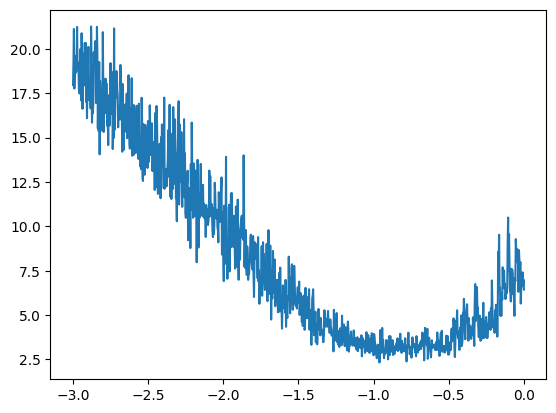

In [36]:
plt.plot(lri, lossi)

Reading the curve: on the left (around 0.001) the loss barely moves, too slow; in the middle it drops fastest; on the right (approaching 1) it turns unstable and starts rising, too large. The sweet spot sits near exponent -1, that is `10^-1 = 0.1`. So 0.1 was a reasonable choice after all, and now I know why. This search is a one-time calibration, not part of real training: run it once, read the chart, pick the rate, reset, and train for real.

## Train / validation / test splits

A lower training loss does not always mean a better model. As a network gets more capacity it can start memorizing the training data verbatim instead of learning patterns, which drives training loss toward zero while performance on unseen names gets worse. That is overfitting, and sampling from such a model just replays the training set.

The standard guard is to split the data three ways: about 80% train, 10% validation (dev), and 10% test. The train split optimizes the parameters. The dev split tunes the hyperparameters (embedding size, hidden size, learning rate, regularization strength) by comparing experiments. The test split is looked at only once, at the very end, to report a final honest number. Peek at the test set repeatedly and tune against it and you start overfitting to it too, so it stops being an unbiased measure. I wrap the dataset builder in a function, shuffle the words, and cut the three splits.

In [37]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


Now I re-initialize and train only on the train split (no peeking at dev or test), using the schedule: 100,000 steps at learning rate 0.1, then a shorter decay phase at 0.01 to settle into the minimum. Then I evaluate the same trained model on the train split and on the dev split.

(The training and evaluation cells below have no saved output on purpose. The numbers depend on the full training run, so a single Restart and Run All fills them in cleanly. Expect roughly 2.3 on both splits for this small model.)

In [38]:
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((27, 2),   generator=g, requires_grad=True)
W1 = torch.randn((6, 100),  generator=g, requires_grad=True)
b1 = torch.randn(100,       generator=g, requires_grad=True)
W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(27,        generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

In [39]:
for i in range(110000):
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update, with a lower rate for the last 10k steps
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(loss.item())

2.0351805686950684


In [40]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
print(F.cross_entropy(logits, Ytr).item())

2.2619149684906006


In [41]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
print(F.cross_entropy(logits, Ydev).item())

2.2644269466400146


## Underfitting: the model is too small

Train loss and dev loss come out about equal, both near 2.2. Equal train and dev loss means the model is not overfitting, it has not memorized anything; it is underfitting, too small to capture the structure in the data. The fix is to scale up, so I make the hidden layer bigger, from 100 neurons to 300.

In [42]:
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((27, 2),   generator=g, requires_grad=True)
W1 = torch.randn((6, 300),  generator=g, requires_grad=True)
b1 = torch.randn(300,       generator=g, requires_grad=True)
W2 = torch.randn((300, 27), generator=g, requires_grad=True)
b2 = torch.randn(27,        generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

In [43]:
sum(p.nelement() for p in parameters)

10281

In [44]:
for i in range(110000):
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update, with a lower rate for the last 10k steps
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(loss.item())

2.2774345874786377


In [45]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
print(F.cross_entropy(logits, Ytr).item())

2.2397141456604004


In [46]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
print(F.cross_entropy(logits, Ydev).item())

2.2444589138031006


Scaling the hidden layer to 300 roughly triples the parameters to 10281. Trained on the same schedule, the loss barely improves, still around 2.2. That is the clue that the hidden layer was not the bottleneck. Before chasing it further, this is a good moment to look at what the 2-dimensional embeddings have learned, because I can only plot them while they are 2-D.

## Visualizing the character embeddings

With 2-dimensional embeddings I can plot `C` directly, each character as a dot at its two coordinates, and see what the network organized on its own.

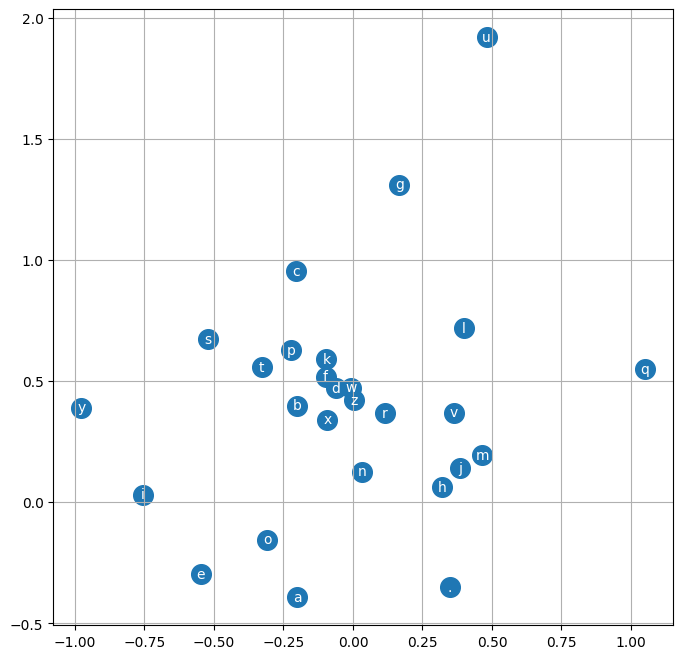

In [47]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

The network was never told anything about vowels, consonants, or similarity; it arranged these purely from which characters follow which across 32k names. Some structure is visible anyway: the vowels `a, e, i, o` tend to group together (the network treats them as somewhat interchangeable), the `.` token and rare characters like `q` sit off on their own, and the rest cluster loosely. The embeddings started as random noise, so the fact that any sensible layout emerged is the point. It also looks cramped, which is the hint that two dimensions is now the real bottleneck: there is not enough room to encode the full set of character relationships.

## Scaling up the embeddings

So the constraint was the embedding size, not the hidden layer. I bump the embedding from 2 to 10 dimensions (which makes the flattened input 3 times 10, so 30) and set the hidden layer to 200 neurons, 11897 parameters. This time I train on the full schedule, 200,000 steps with the learning rate at 0.1 for the first half and 0.01 for the second, and I log `log10(loss)` because it plots as a nicer curve than the raw loss.

In [ ]:
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((27, 10),  generator=g, requires_grad=True)
W1 = torch.randn((30, 200), generator=g, requires_grad=True)
b1 = torch.randn(200,       generator=g, requires_grad=True)
W2 = torch.randn((200, 27), generator=g, requires_grad=True)
b2 = torch.randn(27,        generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

In [51]:
sum(p.nelement() for p in parameters)

11897

In [52]:
stepi = []
lossi = []

for i in range(200000):
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    stepi.append(i)
    lossi.append(loss.log10().item())

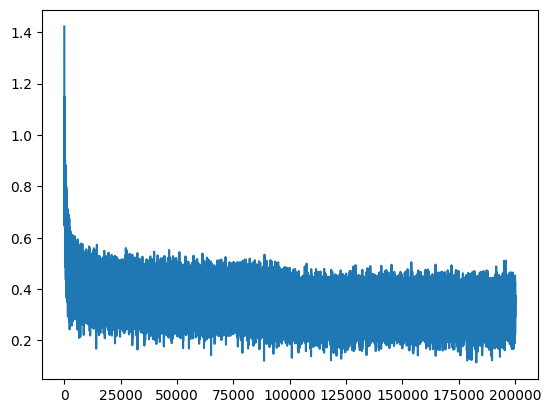

In [53]:
plt.plot(stepi, lossi)

The curve is thick because each point is a noisy mini-batch loss, but the downward trend is clear. On the full splits this model reaches about 2.13 on train and 2.16 on dev, close together (so still not overfitting) and clearly past the bigram model's 2.45. The richer embeddings were indeed what unlocked the improvement.

In [56]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
print(F.cross_entropy(logits, Ytr).item())

2.1310482025146484


In [57]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
print(F.cross_entropy(logits, Ydev).item())

2.1684112548828125


## Sampling from the model

To generate a name I start with the context `[., ., .]`, run the forward pass, softmax the logits into probabilities, sample the next character with `torch.multinomial`, slide it into the context, and repeat until I sample the `.` token. Here `F.softmax` handles the normalization safely, and the context window means each new character is predicted from the previous three.

In [59]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

ceri.
kaimanurailezitah.
melliston.
inralaykina.
da.
samiyah.
jaber.
gotti.
moriella.
ogze.
tedoren.
emiless.
suen.
averny.
fobs.
milliven.
tarlys.
zasdri.
antil.
pennaira.


These are clearly better than last lecture's bigram output (`cexze`, `momasurailezitynn`). Several already read like plausible names, `samiyah` is a real one and `moriella`, `pennaira` are close, because the model now sees three characters of context instead of one and has picked up syllable shapes, common endings, and realistic consonant-vowel patterns. (After a full Restart and Run All on the 200k schedule the samples come from the better-trained model and improve further.)

## Summary

| | Lecture 1 bigram | Lecture 3 MLP |
|---|---|---|
| Context | 1 character | 3 characters |
| Input | one-hot (27-dim) | learned embeddings (10-dim) |
| Architecture | single linear layer | embedding, hidden layer, tanh, output |
| Parameters | 729 | 11897 |
| Loss | 2.48 | 2.16 |

The jump from 2.45 to 2.16 comes straight from context and from learning representations instead of counting. The workflow is the real lesson: build a baseline, measure on a held-out split, find the actual bottleneck (here the embedding size, not the hidden layer), scale the right thing, and repeat. Plenty of knobs remain, more context, a bigger network, a better-tuned optimizer, and the paper itself is worth reading now. The next lectures go after better initialization, batch normalization, and deeper networks, all of it building toward GPT.